## 1 — Config & Imports

In [1]:
import os, math, random
import numpy as np
import pandas as pd
import lightgbm as lgb
from collections import defaultdict

SEED = 42
random.seed(SEED); np.random.seed(SEED)

BASE_DIR = "/Users/jaswanthimandalapu/Documents/Sem2/CMPE 256 (Recommender Systems)/Final Project"
DATA_DIR = os.path.join(BASE_DIR, "llm_rec_data_20interactions")

N_NEG = 100
KS    = [1, 5, 10, 20, 100]

LGB_PARAMS = dict(
    objective         = "lambdarank",
    metric            = "ndcg",
    ndcg_eval_at      = [1, 5, 10, 20],
    label_gain        = [0, 1],
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1,
)
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


## 2 — Load Data

In [2]:
COLS = ["user_idx", "item_idx", "timestamp", "rating"]

train_df = pd.read_parquet(os.path.join(DATA_DIR, "core", "interactions_train.parquet"), columns=COLS)
valid_df = pd.read_parquet(os.path.join(DATA_DIR, "core", "interactions_valid.parquet"), columns=COLS)
test_df  = pd.read_parquet(os.path.join(DATA_DIR, "core", "interactions_test.parquet"),  columns=COLS)

item_meta = pd.read_parquet(os.path.join(DATA_DIR, "item", "item_metadata.parquet"))
user_meta = pd.read_parquet(os.path.join(DATA_DIR, "user", "user_metadata.parquet"))

n_items = item_meta["item_idx"].max() + 1
n_users = user_meta["user_idx"].max() + 1

print(f"Users : {train_df['user_idx'].nunique():,}")
print(f"Items : {n_items:,}")
print(f"Train : {len(train_df):,} interactions")
print(f"Valid : {len(valid_df):,} interactions")
print(f"Test  : {len(test_df):,} interactions")

Users : 46,660
Items : 27,197
Train : 1,306,782 interactions
Valid : 46,660 interactions
Test  : 46,660 interactions


## 3 — Build User Sequences & Sequential Lookups

In [3]:
train_seqs = (
    train_df.sort_values("timestamp")
    .groupby("user_idx")["item_idx"]
    .apply(lambda x: x.to_numpy(dtype=np.int32))
    .to_dict()
)

valid_targets = valid_df.set_index("user_idx")["item_idx"].to_dict()
test_targets  = test_df.set_index("user_idx")["item_idx"].to_dict()

item_geo = item_meta.set_index("item_idx")["geo_id"].to_dict()
item_pop = item_meta.set_index("item_idx")["n_train_reviews"].to_dict()

# ── Transition matrix ─────────────────────────────────────────
print("Building transition matrix...")
transition_counts = defaultdict(int)
for seq in train_seqs.values():
    for i in range(len(seq) - 1):
        transition_counts[(int(seq[i]), int(seq[i+1]))] += 1

outgoing_counts = defaultdict(int)
for (src, _), cnt in transition_counts.items():
    outgoing_counts[src] += cnt

outgoing = defaultdict(dict)
for (src, dst), cnt in transition_counts.items():
    outgoing[src][dst] = cnt

transition_in_counts = defaultdict(int)
for (_, dst), cnt in transition_counts.items():
    transition_in_counts[dst] += cnt

print(f"Transition pairs : {len(transition_counts):,}")

# ── Context feature helper ────────────────────────────────────
RECENCY_DECAY = 0.85   # weight = decay^(steps from end), most recent = 1.0
LAST_K        = 3      # "very recent" window for last-K reach

def context_features(seq):
    pops = np.array([item_pop.get(int(i), 1) for i in seq], dtype=np.float32)
    geos = [item_geo.get(int(i), "") for i in seq]
    N    = len(seq)

    # Uniform history reach (existing)
    reach = defaultdict(float)
    for h in seq:
        for dst, cnt in outgoing.get(int(h), {}).items():
            reach[dst] += cnt

    # Recency-weighted reach: items visited recently get higher weight
    # weight for item at position i (0=oldest) = decay^(N-1-i)
    reach_recency = defaultdict(float)
    for i, h in enumerate(seq):
        w = RECENCY_DECAY ** (N - 1 - i)   # 1.0 for last item, decays backward
        for dst, cnt in outgoing.get(int(h), {}).items():
            reach_recency[dst] += w * cnt

    # Last-K reach: transitions from only the most recent K items
    reach_lastk = defaultdict(float)
    for h in seq[-LAST_K:]:
        for dst, cnt in outgoing.get(int(h), {}).items():
            reach_lastk[dst] += cnt

    total_reach         = float(sum(reach.values()))         or 1.0
    total_reach_recency = float(sum(reach_recency.values())) or 1.0

    return {
        "last_item"            : int(seq[-1]),
        "last_geo"             : geos[-1],
        "geo_set"              : set(geos),
        "mean_item_pop"        : float(pops.mean()),
        "n_distinct_geos"      : len(set(geos)),
        "reach"                : dict(reach),
        "total_reach"          : total_reach,
        "reach_recency"        : dict(reach_recency),
        "total_reach_recency"  : total_reach_recency,
        "reach_lastk"          : dict(reach_lastk),
    }

print("Pre-computing context features for valid / test...")
valid_user_feat = {u: context_features(train_seqs[u]) for u in valid_targets}
test_ctx_seqs   = {u: np.append(train_seqs[u], valid_targets[u]).astype(np.int32)
                   for u in test_targets}
test_user_feat  = {u: context_features(test_ctx_seqs[u]) for u in test_targets}

lengths = [len(s) for s in train_seqs.values()]
print(f"Train seq lengths: min={min(lengths)}  max={max(lengths)}  mean={np.mean(lengths):.1f}")

Building transition matrix...
Transition pairs : 1,215,507
Pre-computing context features for valid / test...
Train seq lengths: min=18  max=9871  mean=28.0


## 4 — Feature Engineering

Features for each **(user, candidate_item)** pair:

| Group | Features |
|---|---|
| **User** | n_reviews, mean_rating, std_rating, user_bias, active_days |
| **Item** | popularity, mean_rating, Bayesian avg, bias, 6 sub-ratings |
| **Sequential** | last geo match, geo in history, geo history count, pop ratio, rating gap, user diversity |

In [4]:
user_meta_idx = user_meta.set_index("user_idx")
item_meta_idx = item_meta.set_index("item_idx")

ITEM_FEAT_COLS = [
    "n_train_reviews", "mean_rating", "bayesian_avg", "item_bias", "std_rating",
    "avg_sub_value", "avg_sub_rooms", "avg_sub_location",
    "avg_sub_cleanliness", "avg_sub_service", "avg_sub_sleep_quality",
]
USER_FEAT_COLS = ["n_train_reviews", "mean_rating", "std_rating", "user_bias", "active_days"]

FEATURE_COLS = (
    [f"u_{c}" for c in USER_FEAT_COLS]
    + [f"i_{c}" for c in ITEM_FEAT_COLS]
    + ["last_geo_match", "geo_in_history", "n_distinct_geos",
       "pop_ratio", "log_pop_ratio", "rating_gap", "bias_product",
       "transition_count", "transition_prob",
       "history_reach_count", "log_history_reach", "history_reach_prob",
       "transition_in_count", "log_trans_in",
       # ── NEW: recency-weighted features ────────────────────
       "recency_reach_count",  # reach weighted by how recently each history item was visited
       "recency_reach_prob",   # normalised recency reach
       "lastk_reach_count",    # reach from only the last 3 visited hotels
       "log_recency_reach",    # log-scaled recency reach
       ]
)
print(f"Total features: {len(FEATURE_COLS)}")


def build_feature_matrix(users, candidates, labels, ctx_feats_list):
    df = pd.DataFrame({"user_idx": users, "item_idx": candidates, "label": labels})

    df = df.join(user_meta_idx[USER_FEAT_COLS].add_prefix("u_"), on="user_idx")
    df = df.join(item_meta_idx[ITEM_FEAT_COLS].add_prefix("i_"), on="item_idx")

    cand_geo   = df["item_idx"].map(item_geo).fillna("").tolist()
    cand_pop   = df["item_idx"].map(item_pop).fillna(1).astype(float)
    cand_idxs  = df["item_idx"].tolist()

    last_geos           = [cf["last_geo"]           for cf in ctx_feats_list]
    geo_sets            = [cf["geo_set"]             for cf in ctx_feats_list]
    mean_pops           = [cf["mean_item_pop"]       for cf in ctx_feats_list]
    last_items          = [cf["last_item"]           for cf in ctx_feats_list]
    n_dist_geos         = [cf["n_distinct_geos"]     for cf in ctx_feats_list]
    reach_dicts         = [cf["reach"]               for cf in ctx_feats_list]
    total_reach         = [cf["total_reach"]         for cf in ctx_feats_list]
    reach_recency_dicts = [cf["reach_recency"]       for cf in ctx_feats_list]
    total_reach_recency = [cf["total_reach_recency"] for cf in ctx_feats_list]
    reach_lastk_dicts   = [cf["reach_lastk"]         for cf in ctx_feats_list]

    df["last_geo_match"]  = [int(cg == lg) for cg, lg in zip(cand_geo, last_geos)]
    df["geo_in_history"]  = [int(cg in gs) for cg, gs in zip(cand_geo, geo_sets)]
    df["n_distinct_geos"] = n_dist_geos
    df["pop_ratio"]       = cand_pop.values / np.clip(mean_pops, 1, None)
    df["log_pop_ratio"]   = np.log1p(cand_pop) - np.log1p(mean_pops)
    df["rating_gap"]      = (df["u_mean_rating"] - df["i_mean_rating"]).abs()
    df["bias_product"]    = df["u_user_bias"] * df["i_item_bias"]

    t_counts = [transition_counts.get((li, ci), 0) for li, ci in zip(last_items, cand_idxs)]
    t_probs  = [cnt / max(outgoing_counts.get(li, 1), 1) for cnt, li in zip(t_counts, last_items)]
    df["transition_count"] = t_counts
    df["transition_prob"]  = t_probs

    h_reach = np.array([rd.get(ci, 0) for rd, ci in zip(reach_dicts, cand_idxs)], dtype=np.float32)
    df["history_reach_count"] = h_reach
    df["log_history_reach"]   = np.log1p(h_reach)
    df["history_reach_prob"]  = h_reach / np.maximum(total_reach, 1.0)

    df["transition_in_count"] = [float(transition_in_counts.get(ci, 0)) for ci in cand_idxs]
    df["log_trans_in"]        = np.log1p(df["transition_in_count"])

    # ── NEW: recency-weighted and last-K reach ─────────────────
    r_reach = np.array([rd.get(ci, 0) for rd, ci in zip(reach_recency_dicts, cand_idxs)], dtype=np.float32)
    df["recency_reach_count"] = r_reach
    df["recency_reach_prob"]  = r_reach / np.maximum(total_reach_recency, 1.0)
    df["log_recency_reach"]   = np.log1p(r_reach)

    lk_reach = np.array([rd.get(ci, 0) for rd, ci in zip(reach_lastk_dicts, cand_idxs)], dtype=np.float32)
    df["lastk_reach_count"]   = lk_reach

    return df[["label"] + FEATURE_COLS]

Total features: 34


## 5 — Build Training Dataset (Sliding Window)

In [5]:
# One LambdaRank query per user — context = train_seq[:-1], positive = train_seq[-1].
# This matches the validation distribution exactly (full context → next item).
# Sliding window was removed: it created a distribution mismatch that inflated
# LightGBM's internal NDCG at tree 1 and caused early stopping to fire immediately.

users_list, items_list, labels_list, ctx_list = [], [], [], []

for u, seq in train_seqs.items():
    seen     = set(seq.tolist())
    ctx      = seq[:-1] if len(seq) > 1 else seq    # context: all but last item
    pos_item = int(seq[-1])                          # item to predict
    cf       = context_features(ctx)

    negs = []
    while len(negs) < N_NEG:
        cands = np.random.randint(0, n_items, size=N_NEG * 2)
        negs += [int(c) for c in cands if c not in seen][:N_NEG - len(negs)]
    negs = negs[:N_NEG]

    for item, lbl in [(pos_item, 1)] + [(neg, 0) for neg in negs]:
        users_list.append(u)
        items_list.append(item)
        labels_list.append(lbl)
        ctx_list.append(cf)

n_queries = len(train_seqs)

print("Building training feature matrix...")
train_feat_df = build_feature_matrix(users_list, items_list, labels_list, ctx_list)
X_train = train_feat_df[FEATURE_COLS].values.astype(np.float32)
y_train = train_feat_df["label"].values.astype(np.int32)
group_train = np.full(n_queries, 1 + N_NEG, dtype=np.int32)

# ── Shuffle within groups ─────────────────────────────────────
# Positive is always built at index 0. LightGBM's stable sort breaks ties by
# original position, so position-0 gives an artificial advantage at tree 1,
# causing LightGBM to think NDCG=0.78 after 1 tree and fire early stopping.
# Shuffling removes this bias so early stopping evaluates honestly.
n_cands = 1 + N_NEG
for q in range(n_queries):
    s    = q * n_cands
    perm = np.random.permutation(n_cands)
    X_train[s:s+n_cands] = X_train[s:s+n_cands][perm]
    y_train[s:s+n_cands] = y_train[s:s+n_cands][perm]

print(f"Training matrix: {X_train.shape}  |  positives: {y_train.sum():,}  (shuffled within groups)")

Building training feature matrix...
Training matrix: (4712660, 34)  |  positives: 46,660  (shuffled within groups)


## 6 — Build Evaluation Datasets (100 Sampled Negatives)

In [6]:
def build_eval_dataset(targets, user_feat, n_items, n_neg, seed=42):
    rng = np.random.default_rng(seed)
    users_list, items_list, labels_list, ctx_list = [], [], [], []

    for u, pos_item in targets.items():
        seen = set(train_seqs.get(u, np.array([], dtype=np.int32)).tolist())
        cf   = user_feat[u]

        negs = []
        while len(negs) < n_neg:
            cands = rng.integers(0, n_items, size=n_neg * 2)
            negs += [int(c) for c in cands if c not in seen and c != pos_item][:n_neg - len(negs)]
        negs = negs[:n_neg]

        for item, lbl in [(pos_item, 1)] + [(neg, 0) for neg in negs]:
            users_list.append(u)
            items_list.append(item)
            labels_list.append(lbl)
            ctx_list.append(cf)

    feat_df = build_feature_matrix(users_list, items_list, labels_list, ctx_list)
    X     = feat_df[FEATURE_COLS].values.astype(np.float32)
    y     = feat_df["label"].values.astype(np.int32)
    group = np.full(len(targets), 1 + n_neg, dtype=np.int32)
    return X, y, group


print("Building validation feature matrix...")
X_val, y_val, group_val = build_eval_dataset(valid_targets, valid_user_feat, n_items, N_NEG)
print(f"Validation matrix: {X_val.shape}")

print("Building test feature matrix...")
X_test, y_test, group_test = build_eval_dataset(test_targets, test_user_feat, n_items, N_NEG)
print(f"Test matrix: {X_test.shape}")

Building validation feature matrix...
Validation matrix: (4712660, 34)
Building test feature matrix...
Test matrix: (4712660, 34)


## 7 — Train LightGBM LambdaRank

In [7]:
lgb_train = lgb.Dataset(X_train, label=y_train, group=group_train,
                         feature_name=FEATURE_COLS, free_raw_data=False)

X_val_shuf = X_val.copy()
y_val_shuf = y_val.copy()
n_cands    = 1 + N_NEG
for u_i in range(len(valid_targets)):
    s    = u_i * n_cands
    perm = np.random.permutation(n_cands)
    X_val_shuf[s:s+n_cands] = X_val[s:s+n_cands][perm]
    y_val_shuf[s:s+n_cands] = y_val[s:s+n_cands][perm]

lgb_val = lgb.Dataset(X_val_shuf, label=y_val_shuf, group=group_val,
                       feature_name=FEATURE_COLS, reference=lgb_train, free_raw_data=False)

print("Training LightGBM LambdaRank...")
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),   # more patience
    lgb.log_evaluation(period=20),
]

ranker = lgb.train(
    LGB_PARAMS,
    lgb_train,
    valid_sets=[lgb_val],
    valid_names=["val"],
    callbacks=callbacks,
)
print(f"\nBest iteration: {ranker.best_iteration}")

Training LightGBM LambdaRank...
Training until validation scores don't improve for 50 rounds
[20]	val's ndcg@1: 0.0588941	val's ndcg@5: 0.0808211	val's ndcg@10: 0.0960838	val's ndcg@20: 0.119534
[40]	val's ndcg@1: 0.0593013	val's ndcg@5: 0.0809542	val's ndcg@10: 0.0962169	val's ndcg@20: 0.119667
[60]	val's ndcg@1: 0.0840334	val's ndcg@5: 0.111533	val's ndcg@10: 0.12611	val's ndcg@20: 0.14863
[80]	val's ndcg@1: 0.0837334	val's ndcg@5: 0.111404	val's ndcg@10: 0.125981	val's ndcg@20: 0.148501
[100]	val's ndcg@1: 0.0836905	val's ndcg@5: 0.111378	val's ndcg@10: 0.125956	val's ndcg@20: 0.148476
Early stopping, best iteration is:
[61]	val's ndcg@1: 0.0840763	val's ndcg@5: 0.111552	val's ndcg@10: 0.126129	val's ndcg@20: 0.148649

Best iteration: 61


## 8 — Evaluation: Hit@K and NDCG@K

In [8]:
def compute_metrics(scores_flat, n_candidates, ks):
    """
    Positive item is always at index 0 in each block of n_candidates scores.
    Rank = number of negatives scoring STRICTLY HIGHER than the positive + 1.
    Using > (not >=) is the standard convention: positive wins ties.
    """
    hits  = {k: 0   for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    n_users = len(scores_flat) // n_candidates

    for i in range(n_users):
        block     = scores_flat[i * n_candidates: (i + 1) * n_candidates]
        pos_score = block[0]
        rank      = int((block[1:] > pos_score).sum()) + 1   # > not >=
        for k in ks:
            if rank <= k:
                hits[k]  += 1
                ndcgs[k] += 1.0 / math.log2(rank + 1)

    return {f"Hit@{k}": hits[k] / n_users for k in ks} | \
           {f"NDCG@{k}": ndcgs[k] / n_users for k in ks}


# Predict on UNSHUFFLED eval data (positive always at index 0)
val_scores  = ranker.predict(X_val,  num_iteration=ranker.best_iteration)
test_scores = ranker.predict(X_test, num_iteration=ranker.best_iteration)

val_metrics  = compute_metrics(val_scores,  1 + N_NEG, KS)
test_metrics = compute_metrics(test_scores, 1 + N_NEG, KS)

results = pd.DataFrame({"Validation": val_metrics, "Test": test_metrics})
results.index.name = "Metric"

print("=" * 60)
print(f"  LightGBM LambdaRank  |  users={len(valid_targets):,}  "
      f"negatives={N_NEG}  trees={ranker.best_iteration}")
print("=" * 60)
display(results.style.format("{:.4f}").set_caption(
    f"Hit@K and NDCG@K — {N_NEG} sampled negatives"))

  LightGBM LambdaRank  |  users=46,660  negatives=100  trees=61


,Validation,Test
Metric,,
Hit@1,0.6953,0.6947
Hit@5,0.9986,0.9983
Hit@10,1.0000,1.0000
Hit@20,1.0000,1.0000
Hit@100,1.0000,1.0000
NDCG@1,0.6953,0.6947
NDCG@5,0.8743,0.8739
NDCG@10,0.8748,0.8745
NDCG@20,0.8748,0.8745


## 9 — Feature Importance

In [11]:
def compute_metrics_tie_aware(scores_flat, labels_flat, n_candidates, ks):
    hits  = {k: 0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    n_users = len(scores_flat) // n_candidates

    for i in range(n_users):
        s = i * n_candidates
        scores = scores_flat[s:s+n_candidates]
        labels = labels_flat[s:s+n_candidates]

        pos_idx = np.where(labels == 1)[0][0]
        pos_score = scores[pos_idx]

        n_higher = np.sum(scores > pos_score)
        n_equal  = np.sum(scores == pos_score)

        # Average tie rank
        rank = n_higher + (n_equal + 1) / 2.0

        for k in ks:
            if rank <= k:
                hits[k] += 1
                ndcgs[k] += 1.0 / math.log2(rank + 1)

    return {f"Hit@{k}": hits[k] / n_users for k in ks} | {
        f"NDCG@{k}": ndcgs[k] / n_users for k in ks
    }

val_metrics_ta  = compute_metrics_tie_aware(val_scores,  y_val,  1 + N_NEG, KS)
test_metrics_ta = compute_metrics_tie_aware(test_scores, y_test, 1 + N_NEG, KS)

results_ta = pd.DataFrame({"Validation": val_metrics_ta, "Test": test_metrics_ta})
results_ta.index.name = "Metric"

print("=" * 60)
print(f"  LightGBM LambdaRank  |  users={len(valid_targets):,}  "
      f"negatives={N_NEG}  trees={ranker.best_iteration}")
print("=" * 60)
display(results_ta.style.format("{:.4f}").set_caption(
    f"Hit@K and NDCG@K — {N_NEG} sampled negatives"))

  LightGBM LambdaRank  |  users=46,660  negatives=100  trees=61


,Validation,Test
Metric,,
Hit@1,0.0782,0.0768
Hit@5,0.0958,0.0944
Hit@10,0.0959,0.0944
Hit@20,0.0959,0.0944
Hit@100,1.0000,1.0000
NDCG@1,0.0782,0.0768
NDCG@5,0.0886,0.0873
NDCG@10,0.0886,0.0873
NDCG@20,0.0886,0.0873


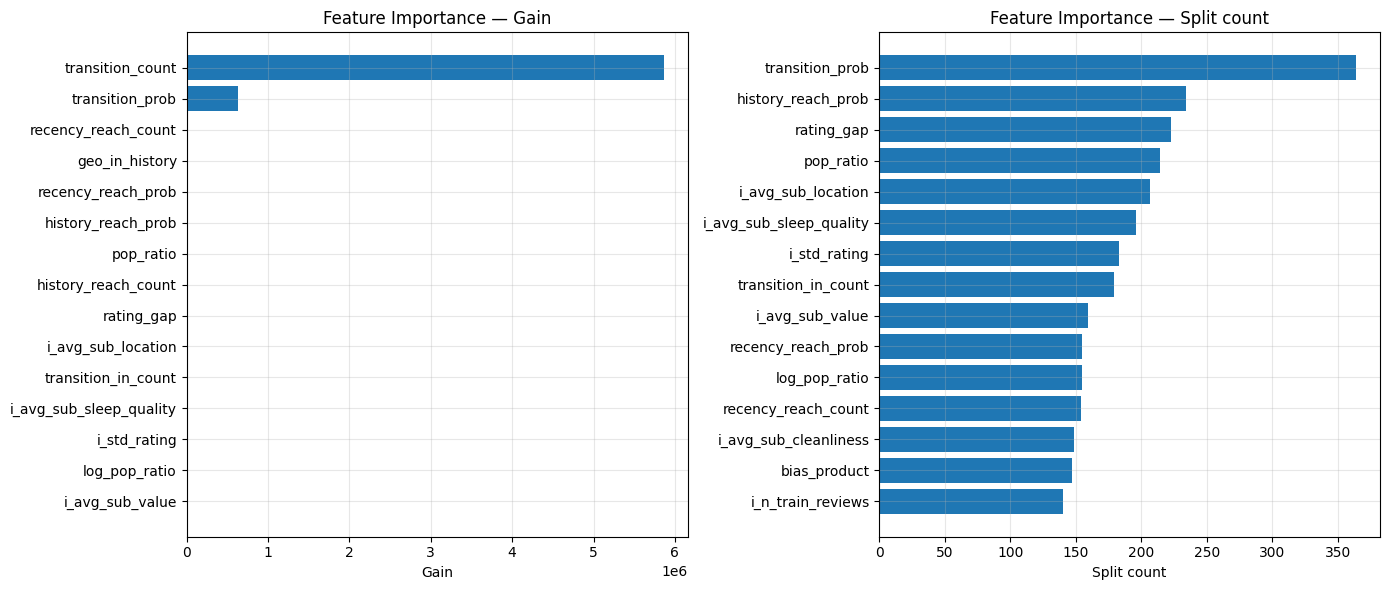


Top-10 features by gain:


,feature,gain,split
23,transition_count,5.861910e+06,52
24,transition_prob,6.314221e+05,364
30,recency_reach_count,1.524518e+04,154
17,geo_in_history,6.581501e+03,113
31,recency_reach_prob,3.932786e+03,155
27,history_reach_prob,3.441223e+03,234
19,pop_ratio,2.489174e+03,214
25,history_reach_count,2.338411e+03,127
21,rating_gap,2.309989e+03,223
12,i_avg_sub_location,2.164978e+03,207


In [9]:
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "feature" : ranker.feature_name(),
    "gain"    : ranker.feature_importance(importance_type="gain"),
    "split"   : ranker.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in zip(axes, ["gain", "split"], ["Gain", "Split count"]):
    top = imp.nlargest(15, col)
    ax.barh(top["feature"][::-1], top[col][::-1])
    ax.set_title(f"Feature Importance — {title}")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "lgbm_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\nTop-10 features by gain:")
display(imp[["feature", "gain", "split"]].head(10))